# MA124 Maths By Computer: Assignment 1

Student number: 2012113

In [1]:
# Import standard libraries

import numpy as np
import matplotlib.pyplot as plt


# A. Perspective of Euclid's orchard

The Euclid's orchard represents "trees" of unit height located on the integer-coordinate points of the first quadrant of the Cartesian plane. When viewed from a corner (the origin), the tops of the trees represent Thomae's function, also known as the modified Dirichlet function. [Thomae's function](https://en.wikipedia.org/wiki/Thomae%27s_function) on $(0,1)$ is given by

$$
f(x) = 
\begin{cases}
  \frac{1}{q} &\text{if } x \in \mathbb Q \text{ and } x = \tfrac{p}{q}, \text{ where } p \in \mathbb N \text{ and } q \in \mathbb N \text{ are coprime}\\
  0           &\text{if }x \text{ is irrational.}
\end{cases}
$$

The graph below represents the [Euclid's orchard](https://en.wikipedia.org/wiki/Euclid%27s_orchard), which plots Thomae's function but with vertical lines going to $y=0~$.

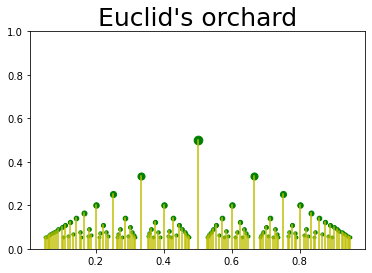

In [2]:
# Python code to compute and plot Euclid's orchard 

for q in range(2,20):               # iterates
    y= 1/q
    for p in range(1,q):            # for a fixed q, iterates over 2/q, 3/q, ... , (q-1)/q.
        if np.gcd(p,q)==1:          # p and q coprime
            x = p/q      
            plt.scatter(x,y, s=150/q, c='g')   # the size of the points varies with q, to give sense of depth
            plt.plot([x,x],[0,y], c='y')
            plt.ylim(0,1)
            plt.title("Euclid\'s orchard", fontsize = 25)
plt.show()           

# B. Taylor approximations to sin(x) and cos(x)

One can approximate $\sin(x)$ using the first $N+1$ terms of a Taylor series:
$$
\sin(x) \simeq \sum_{k=0}^N \frac{(-1)^k}{(2k+1)!} x^{2k+1}
$$

Since $\cos(x) = \frac{d}{dx}\sin(x)$ , differentiating the expression above, one can approximate $\cos(x)$ using the first $N+1$ terms of a Taylor series:
$$
\cos(x) \simeq \sum_{k=0}^N \frac{(-1)^k}{(2k)!} x^{2k}
$$

Therefore, if we choose an array with values of x and set $N$ to be an integer, we can approximate $\sin(x)$ and $\cos(x)$ using Taylor Series. As N increases, the approximation will get closer to the real value.


In [3]:
# Compute Taylor approximations to sin(x) and cos(x)

# Factorial function
def my_factorial(n):
    if n == 0:                    
        return 1                                                # 0! = 1
    else:
        prod = 1
        for k in range(1,n+1):
            prod *= k                                           # n!=n·(n-1)·...·2·1
        return prod

    
x = np.linspace(-2*np.pi,2*np.pi,10)                            # points where we want to evaluate sin(x) and cos(x)
N = 6                                                           # number of terms of the Taylor series used

# Taylor series for sin(x)
def taylor_sin(x,N):
    t = 0
    for k in range(0,N+1):
        t = t + (-1)**k * x**(2*k+1)/my_factorial(2*k+1)        # sin(x) approximation formula    
    return t                 


#Taylor series for cos(x)
def taylor_cos(x,N):
    t = 0
    for k in range(0,N+1):
        t = t + (-1)**k * x**(2*k)/my_factorial(2*k)            # cos(x) approximation formula
    return t

print("For N =",N , "and x =",x)
print()
print()
print("The approximation of sin(x) at x is: \n", taylor_sin(x,N))  
print()
print("The approximation of cos(x) at x is \n", taylor_cos(x,N))    
print()


For N = 6 and x = [-6.28318531 -4.88692191 -3.4906585  -2.0943951  -0.6981317   0.6981317
  2.0943951   3.4906585   4.88692191  6.28318531]


The approximation of sin(x) at x is: 
 [-0.62487654  0.96960674  0.34191831 -0.86602545 -0.64278761  0.64278761
  0.86602545 -0.34191831 -0.96960674  0.62487654]

The approximation of cos(x) at x is 
 [ 2.46528897  0.21978785 -0.93925755 -0.49999965  0.76604444  0.76604444
 -0.49999965 -0.93925755  0.21978785  2.46528897]



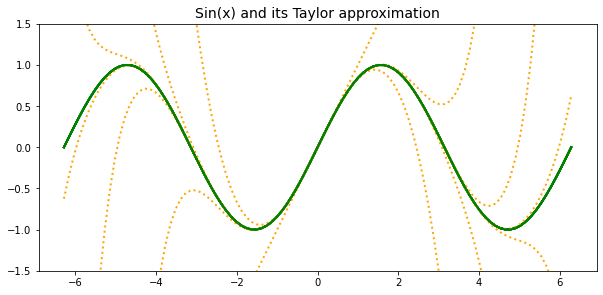

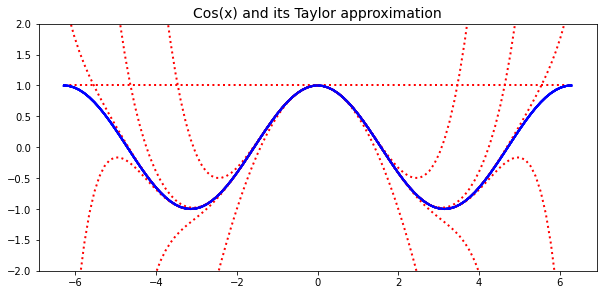

In [4]:
# Plots sin(x) and cos(x) and their respective Taylor approximations.

x1 = np.linspace(-2*np.pi,2*np.pi,101)   # x in (-2𝜋,2𝜋)
y1 = np.sin(x1)
y2 = np.cos(x1)


# Plot of sin(x) and its approximation

fig1 = plt.figure(figsize=(10,10))
ax1 = fig1.add_subplot(211)
for N in range(0,N+1):
    ax1.plot(x1,taylor_sin(x1,N),  color='orange', linestyle=':', linewidth=2)  # plots of the Taylor approximation of sin(x) for all values of N in (0,N)
    ax1.plot(x1, np.sin(x1), color='green', linestyle='-', linewidth=2)         # plot of sin(x)
    plt.ylim(-1.5,1.5)
    plt.title("Sin(x) and its Taylor approximation", fontsize = 14)
    
fig2 = plt.figure(figsize=(10,10))
ax2 = fig2.add_subplot(211)
for N in range(0,N+1):
    ax2.plot(x1,taylor_cos(x1,N), color='red', linestyle=':', linewidth=2)      # plots of the Taylor approximation of cos(x) for all values of n in (0,N)
    ax2.plot(x1,np.cos(x1), color='blue', linestyle='-', linewidth=2)           # plot of cos(x)
    plt.ylim(-2,2)
    plt.title("Cos(x) and its Taylor approximation", fontsize = 14)
plt.show()

The dotted lines represent different approximations to sin(x) and cos(x) for different values of N. The closer the dotted line is to the curve, the bigger N is. 
We can calculate the error for the different values of N by computing $|f(x)-f(x)_{N}|$ where $f(x)$ is $sin(x)$ or $cos(x)$ and $f(x)_{N}$ is the corresponding series approximation.

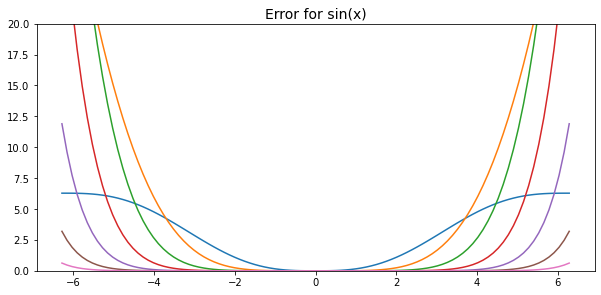

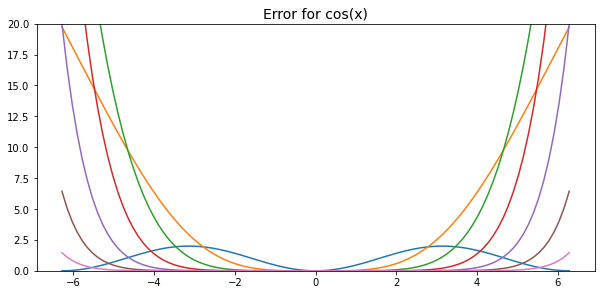

In [5]:
# Compute and plot the error between the real sin(x) and cos(x) and their Taylor approximation for all values of N from 0 to N

# Plot error sin(x) 
x = np.linspace(-2*np.pi,2*np.pi,101)
fig3 = plt.figure(figsize=(10,10))
ax3 = fig3.add_subplot(211)
for N in range(0,N+1):
    y_N1 = abs(np.sin(x)-taylor_sin(x,N))
    ax3.plot(x,y_N1)
    plt.ylim(0, 20)
    plt.title("Error for sin(x)", fontsize=14)
    
# Plot error cos(x)
fig4 = plt.figure(figsize=(10,10))
ax4 = fig4.add_subplot(211)
for N in range(0,N+1):
    y_N2 = abs(np.cos(x)-taylor_cos(x,N))
    ax4.plot(x,y_N2)
    plt.ylim(0,20)
    plt.title("Error for cos(x)", fontsize=14)
    
plt.show()

# C. Parametric roller coaster

Here we present an original design for a parametric roller coaster. The roller coaster consists of 6 curves which do not self intersect. Here are the 6 parametrisations of the curves:

$$x_1 = cos(t),\; y_1 = 1 + sin(t),\; z_1 = 0.2t,\; t \in [0,3\pi]$$

$$x_2 = -2 + sin(t), \; y_2 = cos(t) + 1,\; z_2 = 0.6\pi ,\; t \in [\frac{\pi}{2},\frac{3\pi}{2}]$$

$$x_3 = cos(\frac{\pi}{4}+t)sin(-16t) - 3, \; y_3 = -sin(\frac{\pi}{4}+t)(3+sin(-16t)) + 1, \; z_3 = 0.6\pi + cos(-16t) - 1, \; t \in [\frac{3\pi}{4},\pi]$$

$$x_4 = \frac{tcos(t)}{5} + \frac{3\pi}{5} - 3,\; y_4 = \frac{tsin(t)}{5} +\frac{3\sqrt2}{2} + 1,\; z_4 = 0.2t,\; t \in [0,3\pi]$$

$$x_5 = 4cos(\frac{\pi}{6}-t) + \frac{3\pi}{5} - 3,\; y_5 = 2sin(\frac{\pi}{6}-t) + \frac{3\sqrt2}{2} - 1, \; z_5 = 0, \; t \in [-\frac{\pi}{3},\frac{\pi}{2}]$$

$$x_6 = -1+\frac{3\pi}{5} + (2-\frac{3\pi}{5})t,\; y_6 = -1-\sqrt3 + \frac{3\sqrt2}{2} + (2 + \sqrt3 - \frac{3\sqrt2}{2})t, \; z_6 = 0, \; t \in [0,1]$$



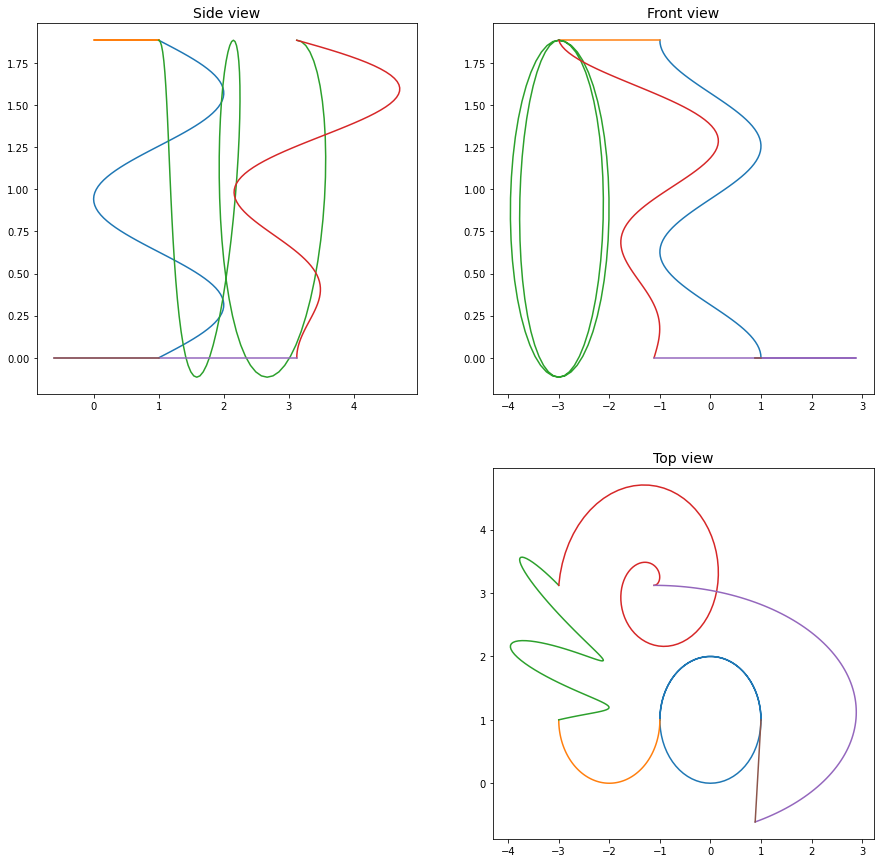

In [6]:
from numpy import pi,cos,sin


# Plot 1 (BLUE)
# Helix starting at (1,1,0) - ending at (-1,1,0.6𝜋) 
t_1 = np.linspace(0,3*pi,101)
x_1 = cos(t_1)
y_1 = 1 + sin(t_1)
z_1 = 0.2*t_1

# Plot 2 (ORANGE)
# Semicircle starting at (-1,1,0.6𝜋) - ending at (-3,1,0.6𝜋) 
t_2 = np.linspace(pi/2,3*pi/2,101)
x_2 = -2 + sin(t_2)
y_2 = cos(t_2) + 1
z_2 = 0.6*pi + 0*t_2

# Plot 3 (GREEN)
# "Fun Feature"  non-intersecting loops starting at (-3,1,0.6𝜋) - ending at (−3+√2/2, 1+3√2/2, 0.6𝜋) 
t_3 = np.linspace(3*pi/4,pi,101)
x_3 = cos(pi/4+t_3)*sin(-16*t_3) - 3
y_3 = -sin(pi/4+t_3)*(3+sin(-16*t_3)) + 1
z_3 = 0.6*pi + cos(-16*t_3) - 1

# Plot 4 (RED)
# Spiral starting at (−3+√2/2, 1+3√2/2, 0.6𝜋) - ending at (-3+3𝜋/5, 1+3√2/2, 0)
t_4 = np.linspace(0,3*pi,101)
x_4 = t_4*cos(t_4)/5 + 3*pi/5 - 3
y_4 = t_4*sin(t_4)/5 +(3*2**0.5)/2 + 1
z_4 = 0.2*t_4

# Plot 5 (PURPLE)
# Ellipse starting at (-3+3𝜋/5, 1+3√2/2, 0) - ending at (-1+3𝜋/5, -1-√3+3√2/2, 0)
t_5 = np.linspace(-pi/3,pi/2,101)
x_5 = 4*cos(pi/6-t_5) + 3*pi/5 - 3
y_5 = 2*sin(pi/6-t_5) + (3*2**0.5)/2 - 1
z_5 = 0*t_5

# Plot 6 (BROWN)
# Line starting at (-1+3𝜋/5, -1-√3+3√2/2, 0) - ending at (1,1,0)
t_6 = np.linspace(0,1,101)
x_6 = -1+3*pi/5 + (2-3*pi/5)*t_6
y_6 = -1-3**0.5 + (3*2**0.5)/2 + (2 + 3**0.5 - (3*2**0.5)/2)*t_6
z_6 = 0*t_6


plt.figure(figsize=(15,15))

# Side view
plt.subplot(221)
plt.plot(y_1,z_1)
plt.plot(y_2,z_2)
plt.plot(y_3,z_3)
plt.plot(y_4,z_4)
plt.plot(y_5,z_5)
plt.plot(y_6,z_6)
plt.title("Side view", fontsize=14)

# Front view
plt.subplot(222)
plt.plot(x_1,z_1)
plt.plot(x_2,z_2)
plt.plot(x_3,z_3)
plt.plot(x_4,z_4)
plt.plot(x_5,z_5)
plt.plot(x_6,z_6)
plt.title("Front view", fontsize=14)

#Top view
plt.subplot(224)
plt.plot(x_1,y_1)
plt.plot(x_2,y_2)
plt.plot(x_3,y_3)
plt.plot(x_4,y_4)
plt.plot(x_5,y_5)
plt.plot(x_6,y_6)
plt.title("Top view", fontsize=14)

plt.show()

The three views represent a three-dimensional closed curve. The blue curve is an helix, the yellow curve is a semicircle, the green curve is the "fun feature", the red curve is an spiral, the purple curve is part of an ellipse and the brown curve is a straight line. The passengers get on the roller coaster at the start of the helix and get off where they started. For passenger safety, the curves do not self-intersect.